# 4. Core Data Science Concepts

**Definition:** Core data science concepts are the main steps and techniques used to collect, prepare, analyze, and model data for useful insights and predictions.

## 1. Data Collection

**Definition:** Data collection is the process of gathering relevant data from sources such as databases, APIs, files, websites, and surveys.

In [2]:
import pandas as pd

data = {
    'Age': [21, 25, 30],
    'Income': [25000, 35000, 50000]
}
df = pd.DataFrame(data)
df

,Age,Income
0,21,25000
1,25,35000
2,30,50000


## 2. Data Cleaning

**Definition:** Data cleaning improves data quality by handling missing values, duplicates, incorrect formats, and inconsistent records.

In [3]:
df = pd.DataFrame({'Age': [21, None, 30], 'Income': [25000, 35000, None]})
df = df.fillna(df.mean(numeric_only=True))
df

,Age,Income
0,21.0,25000.0
1,25.5,35000.0
2,30.0,30000.0


## 3. Exploratory Data Analysis (EDA)

**Definition:** EDA is the process of examining data using statistics and visualizations to understand patterns, relationships, and unusual observations.

In [4]:
import matplotlib.pyplot as plt

df = pd.DataFrame({'Age': [21, 25, 30, 35, 40],
                   'Income': [25000, 32000, 40000, 48000, 60000]})
df.describe()

,Age,Income
count,5.000000,5.000000
mean,30.200000,41000.000000
std,7.596052,13674.794331
min,21.000000,25000.000000
25%,25.000000,32000.000000
50%,30.000000,40000.000000
75%,35.000000,48000.000000
max,40.000000,60000.000000


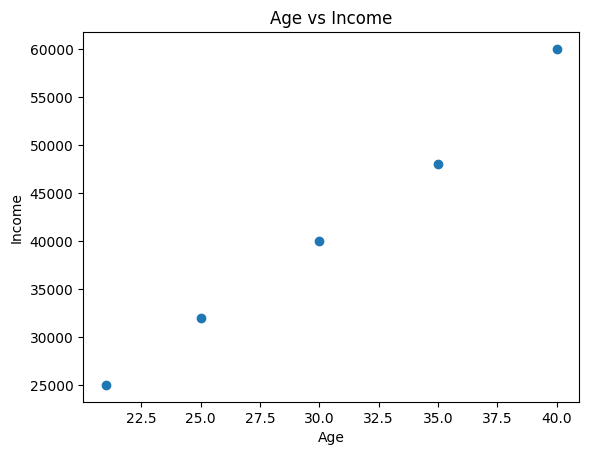

In [5]:
plt.scatter(df['Age'], df['Income'])
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.show()

## 4. Feature Engineering

**Definition:** Feature engineering creates, transforms, or selects useful variables from raw data to improve machine learning model performance.

In [6]:
df['Income_per_Age'] = df['Income'] / df['Age']
df

,Age,Income,Income_per_Age
0,21,25000,1190.476190
1,25,32000,1280.000000
2,30,40000,1333.333333
3,35,48000,1371.428571
4,40,60000,1500.000000


## 5. Train-Test Split

**Definition:** Train-test split divides a dataset into training data for learning and testing data for evaluating how well the model generalizes.

In [7]:
from sklearn.model_selection import train_test_split

X = df[['Age']]
y = df['Income']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_test

(   Age
 4   40
 2   30
 0   21
 3   35,
    Age
 1   25)

## 6. Supervised Learning

**Definition:** Supervised learning trains a model using labeled data to predict a target value for new observations.

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
model.predict(X_test)

array([31520.30456853])

## 7. Unsupervised Learning

**Definition:** Unsupervised learning finds hidden patterns or groups in data without using predefined target labels.

In [9]:
from sklearn.cluster import KMeans

X_cluster = df[['Age', 'Income']]
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_cluster)
df

,Age,Income,Income_per_Age,Cluster
0,21,25000,1190.476190,0
1,25,32000,1280.000000,0
2,30,40000,1333.333333,0
3,35,48000,1371.428571,1
4,40,60000,1500.000000,1


## 8. Model Evaluation

**Definition:** Model evaluation measures how accurately and reliably a machine learning model performs on unseen data using suitable evaluation metrics.

In [10]:
from sklearn.metrics import mean_absolute_error

predictions = model.predict(X_test)
mae = mean_absolute_error(y_test, predictions)
print('MAE:', mae)

MAE: 479.6954314720788


## 9. Overfitting and Underfitting

**Overfitting:** A model learns the training data too closely and performs poorly on unseen data.

**Underfitting:** A model is too simple to learn important patterns from the data.

## 10. Data Leakage

**Definition:** Data leakage occurs when information that should not be available during training is used by the model, causing unrealistically good results.

**Example:** Using test-set information while preparing training features.

# Summary

- Data Collection → Gather data
- Data Cleaning → Improve data quality
- EDA → Understand data
- Feature Engineering → Create useful features
- Train-Test Split → Separate learning and evaluation data
- Supervised Learning → Learn from labeled data
- Unsupervised Learning → Find patterns without labels
- Model Evaluation → Measure model performance
- Overfitting/Underfitting → Identify model complexity problems
- Data Leakage → Prevent unintended information from entering the model